# HR Analytics

## Import Library

In [888]:
import kaggle
import pandas as pd
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [889]:
# Import dataset
!kaggle datasets download mahmoudemadabdallah/hr-analytics-employee-attrition-and-performance --unzip

Dataset URL: https://www.kaggle.com/datasets/mahmoudemadabdallah/hr-analytics-employee-attrition-and-performance
License(s): other




  0%|          | 0.00/147k [00:00<?, ?B/s]
100%|██████████| 147k/147k [00:00<00:00, 248kB/s]
100%|██████████| 147k/147k [00:00<00:00, 247kB/s]


In [890]:
em = pd.read_csv('Employee.csv')
el = pd.read_csv('EducationLevel.csv')
pr = pd.read_csv('PerformanceRating.csv')

In [891]:
em

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,Divorced,102059,1,No,2012-01-03,No,10,4,9,7
1,CBCB-9C9D,Leonerd,Aland,Male,38,Some Travel,Sales,23,CA,White,...,Single,157718,0,Yes,2012-01-04,No,10,6,10,0
2,95D7-1CE9,Ahmed,Sykes,Male,43,Some Travel,Human Resources,29,CA,Asian or Asian American,...,Married,309964,1,No,2012-01-04,No,10,6,10,8
3,47A0-559B,Ermentrude,Berrie,Non-Binary,39,Some Travel,Technology,12,IL,White,...,Married,293132,0,No,2012-01-05,No,10,10,10,0
4,42CC-040A,Stace,Savege,Female,29,Some Travel,Human Resources,29,CA,White,...,Single,49606,0,No,2012-01-05,Yes,6,1,1,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,467E-977A,Jud,Melanaphy,Male,20,Some Travel,Technology,28,CA,Black or African American,...,Single,38508,0,No,2022-12-26,No,0,0,0,0
1466,6FB9-A624,Marc,Calver,Non-Binary,27,Some Travel,Technology,8,CA,Black or African American,...,Single,92995,3,No,2022-12-30,No,0,0,0,0
1467,EBF4-5928,Rudolph,MacDearmont,Male,21,Some Travel,Sales,4,CA,Black or African American,...,Single,63375,0,No,2022-12-30,No,0,0,0,0
1468,60E6-B1D9,Merill,Agg,Male,21,Some Travel,Technology,7,CA,Black or African American,...,Married,46521,0,No,2022-12-30,No,0,0,0,0


In [892]:
el

,EducationLevelID,EducationLevel
0,1,No Formal Qualifications
1,2,High School
2,3,Bachelors
3,4,Masters
4,5,Doctorate


In [893]:
pr.head()

,PerformanceID,EmployeeID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating
0,PR01,79F7-78EC,1/2/2013,5,4,5,1,0,4,4,4
1,PR02,B61E-0F26,1/3/2013,5,4,4,1,3,4,4,3
2,PR03,F5E3-48BB,1/3/2013,3,4,5,3,2,3,5,4
3,PR04,0678-748A,1/4/2013,5,3,2,2,0,2,3,2
4,PR05,541F-3E19,1/4/2013,5,2,3,1,0,4,4,3


## Data Cleaning

In [894]:
pd.set_option('display.max_colwidth', None) 

### Employee

In [895]:
# Check Unique
kolom = list(em.columns)

container = []
for col in kolom:
  container.append([col, em[col].nunique(), em[col].unique()])

Unique = pd.DataFrame(columns=['kolom', 'nunique', 'unique_values'], data=container)
Unique

,kolom,nunique,unique_values
0,EmployeeID,1470,"[3012-1A41, CBCB-9C9D, 95D7-1CE9, 47A0-559B, 42CC-040A, C219-6C2E, D906-B674, 3C7D-86ED, 3D71-8DC2, 5476-CA0D, 73CF-4956, 277A-A6FA, 8BAB-B4A6, 111D-E5EF, 97F4-0B14, 5C03-1009, BD1B-53A3, DFA9-990E, ED73-F078, C6EC-FEB5, D7EE-56FC, C395-8C36, E348-E12B, B3AF-7E58, 469A-8121, 9E22-6287, D5DA-363A, BFF3-AADC, C0BE-FED0, D565-284D, 00D4-DD53, 7FFD-C810, 07B2-D67A, 1749-81A2, FF14-A43E, 3CD6-5587, 4FC2-A40D, 9AAB-DCD0, 427A-8C69, A923-9EF6, 5C61-8F3A, CF2F-8CA3, 40A9-8EB0, 2E72-4BF1, EE39-C8F2, C0C7-A3EF, 79F3-8AA5, 9528-AA17, 9C71-34AE, C79A-E5E1, 5468-EEE1, B50B-5A18, 11AE-3E4D, 151D-1FF2, D584-4E31, 0FC8-561B, A531-8159, E7A6-33A3, E4F4-11B9, 586E-5C14, 8A40-C85A, 2B08-7D3D, C96F-0F3B, 9DFE-1FD5, C0A1-EB7D, 5731-90E6, FD3F-5255, 132B-F2B2, 9DB2-76B3, 4969-9A35, 0CED-EE28, D077-169C, 63DA-AA21, ACA9-5DC2, 12B5-11CC, 00A3-2445, 076F-8AA3, 3F19-FC5A, 8233-2483, 1C87-44CB, 6345-2F33, A2FB-2D5D, E5C1-B122, 462E-03DF, C2DD-9D37, AEDB-BB62, 88B8-EB84, 8822-B9C5, E8F5-C47D, D696-9D82, BE93-0736, 0322-D46B, 1E61-70EC, 5222-EBE1, DEBE-1622, A366-C17A, 2962-039F, 21CB-EF3E, 9727-BC84, 68FB-06A7, ...]"
1,FirstName,1334,"[Leonelle, Leonerd, Ahmed, Ermentrude, Stace, Clerkclaude, Uta, Joyan, Alix, Kayley, Hannis, Annabela, Torey, Edna, Vernen, Willetta, Wendall, Cale, Ernaline, Charlena, Zsa zsa, Curcio, Burnaby, Elvira, Baxie, Gifford, Rickey, Collen, Bertram, Bessie, Joyce, Claresta, Rossie, Elora, Koenraad, Dorise, Gayle, Staci, Pasquale, Alaine, Dyana, Lindy, Joannes, Grace, Jaclin, Hagen, Lacy, Jaquelin, Yvor, Alvera, Forbes, Paulina, Sheffie, Kai, Patrica, Caryl, Carlyn, Amye, Susanne, Gunther, Reggie, Roderic, Jessa, Angel, Leona, Leonidas, Quintilla, Erica, Buck, Thekla, Ruthy, Gustavo, Diannne, Mireielle, Vitoria, Wyatt, Reese, Hy, Sheba, Darlene, Ignacius, Lebbie, Camila, Muffin, Ring, Munmro, Crystal, Amity, Jayne, Eberto, Lucas, Nikolas, Addison, Saxe, Bartolemo, Jodie, Darice, Eleanora, Murdock, Elle, ...]"
2,LastName,1441,"[Simco, Aland, Sykes, Berrie, Savege, Hinkins, Melmar, Brason, Blazejewski, Snoad, Waslin, Pablos, Abram, Alison, Powner, Lurriman, Dryden, Holston, Napolione, Severwright, Evered, Franek, Guillet, Ianelli, Rising, Poynser, Shere, Sedman, Doleman, Bellson, Goor, Impy, Everleigh, Bentjens, Nannizzi, Klishin, Riseley, Leith, Abreheart, Hinrichsen, Gallie, Rawstorne, McFadden, Gohier, Chadburn, Worge, Domerc, Kite, Walaron, Kulver, Toretta, Senecaut, Tonkin, Lush, Lamyman, Loving, Pavese, Townes, Wisam, Keays, Matthewman, Daddow, Glasscoo, Hazeup, McKnish, Clarke-Williams, Wyllt, Dracksford, Klawi, Flintuff, Pena, Chatel, Choules, Chstney, MacVaugh, Ziehm, Dibbert, Trevance, McCromley, Mansbridge, Streeter, Poure, Hernik, Ellcome, Genge, Ledamun, McLleese, Kalisz, Mickleburgh, Flaherty, Oran, Leslie, Elfe, Theodoris, Balma, Le Breton De La Vieuville, Excell, Thornbarrow, Spaduzza, Balcombe, ...]"
3,Gender,4,"[Female, Male, Non-Binary, Prefer Not To Say]"
4,Age,34,"[30, 38, 43, 39, 29, 34, 42, 40, 31, 32, 35, 37, 33, 45, 36, 48, 47, 44, 28, 41, 46, 27, 26, 25, 24, 23, 22, 21, 49, 50, 20, 19, 51, 18]"
5,BusinessTravel,3,"[Some Travel, No Travel , Frequent Traveller]"
6,Department,3,"[Sales, Human Resources, Technology]"
7,DistanceFromHome (KM),45,"[27, 23, 29, 12, 30, 45, 3, 20, 4, 42, 8, 35, 21, 34, 19, 1, 17, 36, 37, 41, 25, 44, 22, 40, 14, 15, 7, 5, 31, 9, 13, 38, 16, 39, 28, 32, 2, 6, 11, 33, 26, 43, 10, 18, 24]"
8,State,3,"[IL, CA, NY]"
9,Ethnicity,7,"[White, Asian or Asian American, Mixed or multiple ethnic groups, Black or African American, Native Hawaiian , Other , American Indian or Alaska Native]"


In [896]:
# Check data type
em.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   EmployeeID               1470 non-null   object
 1   FirstName                1470 non-null   object
 2   LastName                 1470 non-null   object
 3   Gender                   1470 non-null   object
 4   Age                      1470 non-null   int64 
 5   BusinessTravel           1470 non-null   object
 6   Department               1470 non-null   object
 7   DistanceFromHome (KM)    1470 non-null   int64 
 8   State                    1470 non-null   object
 9   Ethnicity                1470 non-null   object
 10  Education                1470 non-null   int64 
 11  EducationField           1470 non-null   object
 12  JobRole                  1470 non-null   object
 13  MaritalStatus            1470 non-null   object
 14  Salary                   1470 non-null  

In [897]:
# em['HireDate'] = pd.to_datetime(em['HireDate'], format='%Y-%m-%d', errors='coerce') 

#yang bener
em['HireDate'] = pd.to_datetime(em['HireDate'])

In [898]:
# Check missing value
em.isnull().sum()

EmployeeID                 0
FirstName                  0
LastName                   0
Gender                     0
Age                        0
BusinessTravel             0
Department                 0
DistanceFromHome (KM)      0
State                      0
Ethnicity                  0
Education                  0
EducationField             0
JobRole                    0
MaritalStatus              0
Salary                     0
StockOptionLevel           0
OverTime                   0
HireDate                   0
Attrition                  0
YearsAtCompany             0
YearsInMostRecentRole      0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64

In [899]:
# Check duplicate
em.duplicated().sum()

0

In [900]:
em.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   EmployeeID               1470 non-null   object        
 1   FirstName                1470 non-null   object        
 2   LastName                 1470 non-null   object        
 3   Gender                   1470 non-null   object        
 4   Age                      1470 non-null   int64         
 5   BusinessTravel           1470 non-null   object        
 6   Department               1470 non-null   object        
 7   DistanceFromHome (KM)    1470 non-null   int64         
 8   State                    1470 non-null   object        
 9   Ethnicity                1470 non-null   object        
 10  Education                1470 non-null   int64         
 11  EducationField           1470 non-null   object        
 12  JobRole                  1470 non-

As part of the data cleaning process, I noticed that there were no duplicate or missing values in the employee table, which is great. However, I observed that the HireDate column was not in the correct datetime format. This could cause issues when analyzing trends over time or performing any time-based calculation, so we change the dtype. 

### Education Level

In [901]:
# Check Unique
kolom = list(el.columns)

container = []
for col in kolom:
  container.append([col, el[col].nunique(), el[col].unique()])

Unique = pd.DataFrame(columns=['kolom', 'nunique', 'unique_values'], data=container)
Unique

,kolom,nunique,unique_values
0,EducationLevelID,5,"[1, 2, 3, 4, 5]"
1,EducationLevel,5,"[No Formal Qualifications, High School , Bachelors , Masters , Doctorate]"


In [902]:
# Check general info
el.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   EducationLevelID  5 non-null      int64 
 1   EducationLevel    5 non-null      object
dtypes: int64(1), object(1)
memory usage: 208.0+ bytes


In [903]:
# Check missing values
el.isnull().sum()

EducationLevelID    0
EducationLevel      0
dtype: int64

In [904]:
# Check duplicate
el.duplicated().sum()  

0

All the data in the EducationLevel table is accurate and properly formatted, no additional cleaning is necessary. We can be confident that the data is ready for analysis.



### Performance Rating

In [905]:
# Check Unique
kolom = list(pr.columns)

container = []
for col in kolom:
  container.append([col, pr[col].nunique(), pr[col].unique()])

Unique = pd.DataFrame(columns=['kolom', 'nunique', 'unique_values'], data=container)
Unique

,kolom,nunique,unique_values
0,PerformanceID,6709,"[PR01, PR02, PR03, PR04, PR05, PR06, PR07, PR08, PR09, PR10, PR100, PR1000, PR1001, PR1002, PR1003, PR1004, PR1005, PR1006, PR1007, PR1008, PR1009, PR101, PR1010, PR1011, PR1012, PR1013, PR1014, PR1015, PR1016, PR1017, PR1018, PR1019, PR102, PR1020, PR1021, PR1022, PR1023, PR1024, PR1025, PR1026, PR1027, PR1028, PR1029, PR103, PR1030, PR1031, PR1032, PR1033, PR1034, PR1035, PR1036, PR1037, PR1038, PR1039, PR104, PR1040, PR1041, PR1042, PR1043, PR1044, PR1045, PR1046, PR1047, PR1048, PR1049, PR105, PR1050, PR1051, PR1052, PR1053, PR1054, PR1055, PR1056, PR1057, PR1058, PR1059, PR106, PR1060, PR1061, PR1062, PR1063, PR1064, PR1065, PR1066, PR1067, PR1068, PR1069, PR107, PR1070, PR1071, PR1072, PR1073, PR1074, PR1075, PR1076, PR1077, PR1078, PR1079, PR108, PR1080, ...]"
1,EmployeeID,1280,"[79F7-78EC, B61E-0F26, F5E3-48BB, 0678-748A, 541F-3E19, F93E-BDEF, 9E7A-1F70, 05ED-92F1, F72D-261D, 774E-685D, B013-7D0C, 528C-3E0D, D077-169C, 9727-BC84, DA8E-9496, DEC5-9319, 88B8-EB84, 9C57-828C, E1B4-9AA1, 3CD6-5587, BAFA-86DF, 152E-8DB1, C6D7-A568, 5160-53BD, 81FF-8D6C, 84E7-02D4, 6010-A052, 6176-3BEE, 47A0-559B, A954-6310, C525-8BB9, 9AAB-DCD0, 52CC-3E9E, 00E4-3D60, 03C5-51AD, A807-DE5D, DD04-BDF8, 8FD9-AA59, 86E2-73D1, 1A6D-AF5D, 0210-E0D8, 07B2-D67A, 819A-2C9C, C5C2-985F, B6EC-313E, 0D8F-C0F3, 1799-5B3F, 3B11-DF28, 076F-8AA3, 95D7-1CE9, 531D-788E, AEDB-BB62, F430-0404, CDFB-6A08, 7BD4-7BFB, 1A7C-19DB, 489B-14EC, A531-8159, 5C03-1009, E899-A860, EE91-1A9C, 7CFC-C4DA, CF2F-8CA3, 7A98-768E, C3C0-349E, 96F4-896C, B52E-BF41, 5D69-D350, 4BE1-4A7B, AB81-A3A0, FD3F-5255, C661-6A1C, C025-B8B6, 9528-AA17, 4188-C61D, DFE3-6FA7, 7335-4656, 49B2-0364, 51A4-EA6E, A4A4-F49C, BAF9-933D, 1147-7E2F, 4E65-CCD0, 1AC8-361F, D93A-CC98, C79A-E5E1, A1B4-5481, D49C-096C, 2F04-931F, 380E-44B4, 327B-F6D3, B148-55FB, EB4F-4D97, 1472-9F69, 59DB-8465, D31B-BEF8, 565B-C207, 13E5-2F17, ADF8-AD57, FE2B-3DC7, ...]"
2,ReviewDate,2771,"[1/2/2013, 1/3/2013, 1/4/2013, 1/8/2013, 1/10/2013, 1/11/2013, 4/10/2013, 3/16/2016, 3/17/2016, 3/18/2016, 3/19/2016, 3/22/2016, 3/23/2016, 4/12/2013, 3/24/2016, 3/25/2016, 3/27/2016, 3/28/2016, 4/13/2013, 3/29/2016, 3/30/2016, 3/31/2016, 4/1/2016, 4/2/2016, 4/14/2013, 4/3/2016, 4/5/2016, 4/6/2016, 4/8/2016, 4/9/2016, 4/10/2016, 4/11/2016, 4/12/2016, 4/13/2016, 4/15/2013, 4/14/2016, 4/16/2016, 4/17/2016, 4/18/2016, 4/18/2013, 4/19/2016, 4/20/2016, 4/21/2016, 4/22/2016, 4/23/2016, 4/24/2016, 4/21/2013, 4/25/2016, 4/26/2016, 4/28/2016, 4/29/2016, 4/30/2016, 4/23/2013, 5/1/2016, 5/2/2016, 5/3/2016, 5/4/2016, 5/5/2016, 5/6/2016, 5/7/2016, 5/8/2016, 5/9/2016, 5/10/2016, 5/11/2016, 5/12/2016, 5/13/2016, 5/14/2016, 5/15/2016, 5/16/2016, 5/17/2016, 5/18/2016, 5/19/2016, 4/25/2013, 5/20/2016, 5/21/2016, 5/22/2016, 5/23/2016, 5/24/2016, 4/26/2013, 5/26/2016, 5/27/2016, 5/28/2016, 5/29/2016, 4/27/2013, 5/31/2016, 6/1/2016, 6/3/2016, 6/4/2016, 6/5/2016, 6/6/2016, 6/9/2016, 6/10/2016, 6/12/2016, 6/13/2016, 6/14/2016, 4/29/2013, 6/16/2016, 6/17/2016, 6/19/2016, 6/21/2016, ...]"
3,EnvironmentSatisfaction,5,"[5, 3, 4, 1, 2]"
4,JobSatisfaction,5,"[4, 3, 2, 5, 1]"
5,RelationshipSatisfaction,5,"[5, 4, 2, 3, 1]"
6,TrainingOpportunitiesWithinYear,3,"[1, 3, 2]"
7,TrainingOpportunitiesTaken,4,"[0, 3, 2, 1]"
8,WorkLifeBalance,5,"[4, 3, 2, 5, 1]"
9,SelfRating,3,"[4, 5, 3]"


In [906]:
# Check Dtype
pr.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6709 entries, 0 to 6708
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   PerformanceID                    6709 non-null   object
 1   EmployeeID                       6709 non-null   object
 2   ReviewDate                       6709 non-null   object
 3   EnvironmentSatisfaction          6709 non-null   int64 
 4   JobSatisfaction                  6709 non-null   int64 
 5   RelationshipSatisfaction         6709 non-null   int64 
 6   TrainingOpportunitiesWithinYear  6709 non-null   int64 
 7   TrainingOpportunitiesTaken       6709 non-null   int64 
 8   WorkLifeBalance                  6709 non-null   int64 
 9   SelfRating                       6709 non-null   int64 
 10  ManagerRating                    6709 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 576.7+ KB


In [907]:
# data type to datetime
# pr['ReviewDate'] = pd.to_datetime(pr['ReviewDate'], format='%m/%d/%Y', errors='coerce')

# Yang bener 
pr['ReviewDate'] = pd.to_datetime(pr['ReviewDate'], format='%m/%d/%Y')


In [908]:
pr

,PerformanceID,EmployeeID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating
0,PR01,79F7-78EC,2013-01-02,5,4,5,1,0,4,4,4
1,PR02,B61E-0F26,2013-01-03,5,4,4,1,3,4,4,3
2,PR03,F5E3-48BB,2013-01-03,3,4,5,3,2,3,5,4
3,PR04,0678-748A,2013-01-04,5,3,2,2,0,2,3,2
4,PR05,541F-3E19,2013-01-04,5,2,3,1,0,4,4,3
...,...,...,...,...,...,...,...,...,...,...,...
6704,PR995,4F28-CFAF,2016-03-14,5,3,3,3,1,5,5,4
6705,PR996,7C80-94E0,2016-03-14,3,5,4,2,1,3,4,4
6706,PR997,8233-2483,2016-03-14,3,4,2,3,1,2,3,2
6707,PR998,8A5B-3D6E,2016-03-15,5,2,5,2,2,4,3,3


In [909]:
# Missing value
pr.isnull().sum()

PerformanceID                      0
EmployeeID                         0
ReviewDate                         0
EnvironmentSatisfaction            0
JobSatisfaction                    0
RelationshipSatisfaction           0
TrainingOpportunitiesWithinYear    0
TrainingOpportunitiesTaken         0
WorkLifeBalance                    0
SelfRating                         0
ManagerRating                      0
dtype: int64

In [910]:
# Check duplicate
pr.duplicated().sum()

0

For the PerformanceRating table, it's good that we identified the issue with the `ReviewDate` column not having the correct datetime format. We can address this by converting it to a datetime format just like we did with `HireDate` in the `Employee` table. Since there is a format inconsistency between the two tables (`HireDate` in `Employee` and `ReviewDate` in `Performance`), it's essential to standardize the format across both tables to maintain consistency and make analysis easier.

## Load Database

### To PostgreSQL

In [911]:
# Define parameter
username = 'postgres'
password = 'postgres'
host = 'localhost'
port = '5432'
database = 'DataAnalysis'

# Define Engine SQLAlchemy
engine = create_engine(f'postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}')

# Simpan DataFrame ke PostgreSQL  
em.to_sql('Employee', engine, if_exists='replace', index=False)
el.to_sql('EducationLevel', engine, if_exists='replace', index=False)
pr.to_sql('PerformanceRating', engine, if_exists='replace', index=False)

709

In [912]:
# Define Primary dan Foreign Key (DDL)
add_primary_key_employee = text("""  
ALTER TABLE "Employee"  
ADD CONSTRAINT pk_employee PRIMARY KEY ("EmployeeID");  
""")  
  
add_primary_key_educationlevel = text("""  
ALTER TABLE "EducationLevel"  
ADD CONSTRAINT pk_educationlevel PRIMARY KEY ("EducationLevelID");  
""")  
  
add_primary_key_performance = text("""  
ALTER TABLE "PerformanceRating"  
ADD CONSTRAINT pk_performance PRIMARY KEY ("PerformanceID");  
""")  
  
add_foreign_key_performance_employee = text("""  
ALTER TABLE "PerformanceRating"  
ADD CONSTRAINT fk_performance_employee  
FOREIGN KEY ("EmployeeID")  
REFERENCES "Employee"("EmployeeID");  
""")  
  
add_foreign_key_employee_educationlevel = text("""  
ALTER TABLE "Employee"  
ADD CONSTRAINT fk_employee_educationlevel  
FOREIGN KEY ("Education")  
REFERENCES "EducationLevel"("EducationLevelID");  
""")  
  
# Eksekusi DDL  
with engine.connect() as connection:  
    try:  
        connection.execute(add_primary_key_employee)  
        connection.execute(add_primary_key_educationlevel)  
        connection.execute(add_primary_key_performance)  
        connection.execute(add_foreign_key_performance_employee)  
        connection.execute(add_foreign_key_employee_educationlevel)  
        print("DDL statements executed successfully.")  
    except Exception as e:  
        print(f"Error executing DDL statements: {e}") 

DDL statements executed successfully.


After cleaning the data and loading it into PostgreSQL, defining the appropriate primary keys (PK) and foreign keys (FK) is crucial for ensuring data integrity and enabling efficient relationships between tables. Here's how I would go about this:
- Define Primary Key: Each table should have a unique identifier, which is typically the primary key. The Column contains keyword "ID" will be the primary key.
- Define Foreign Key: Foreign keys will ensure that relationships between tables are correctly enforced, making sure that data from one table corresponds to valid entries in another table. Foreign key 

These are the relation between tables:
- Employee Table: EmployeeID is the primary key.
- EducationLevel Table: EducationLevelID is the primary key.
- PerformanceRating Table: PerformanceID is the primary key, and EmployeeID is a foreign key referencing Employee(EmployeeID).
- Employee Table: Education (likely representing EducationLevelID) is a foreign key referencing EducationLevel(EducationLevelID).

### Or to CSV manually

In [913]:
# Atau bisa juga langsung menjadi csv di local
em.to_csv('Employee.csv', index=False)
el.to_csv('EducationLevel.csv', index=False)
pr.to_csv('PerformanceRating.csv', index=False)

We will use Tableau Public for viz and since the free edition has limitations when directly connecting to PostgreSQL, using CSV files for manual uploads is a practical workaround to visualize the data. Here’s a simple approach to manually export data from PostgreSQL to CSV, followed by steps to upload it into Tableau Public for visualization.

## **Exploratory Data Analysis**

### **Attrition Rate**

In [914]:
# Total Employees
total_employees = em.shape[0]

# Current Employees
current_employees = em[em['Attrition'] == 'No'].shape[0]

# Past Employees
resigned_employees = em[em['Attrition'] == 'Yes'].shape[0]

# Attrition Rate
attrition_rate = (resigned_employees / total_employees) * 100

print(f'Total Employees     : {total_employees}')
print(f'Current Employees   : {current_employees}')
print(f'Past Employees      : {resigned_employees}')
print(f'Attrition Rate      : {attrition_rate:.2f}%')


Total Employees     : 1470
Current Employees   : 1233
Past Employees      : 237
Attrition Rate      : 16.12%


The fact that only 16.12% of employees have left over the last 10 years is indeed a good indicator of employee retention, which often correlates with a healthy, well-managed company. Low employee turnover can indicate a variety of positive aspects, including:

- Job Satisfaction: Employees may feel more satisfied and engaged with their roles, which could contribute to a stable workforce.
- Effective Management: The company’s management may be strong in terms of leadership, career development opportunities, and employee relations.
- Competitive Compensation and Benefits: Retention can be a sign that the company offers attractive compensation packages and benefits, ensuring employees are satisfied with their work environment.
- Work-Life Balance: A company that supports work-life balance often has lower turnover because employees feel that their well-being is valued.
- Opportunities for Growth: Employees who see clear career advancement opportunities are less likely to leave, leading to longer tenures.

### **Attrition and Hiring Trend**


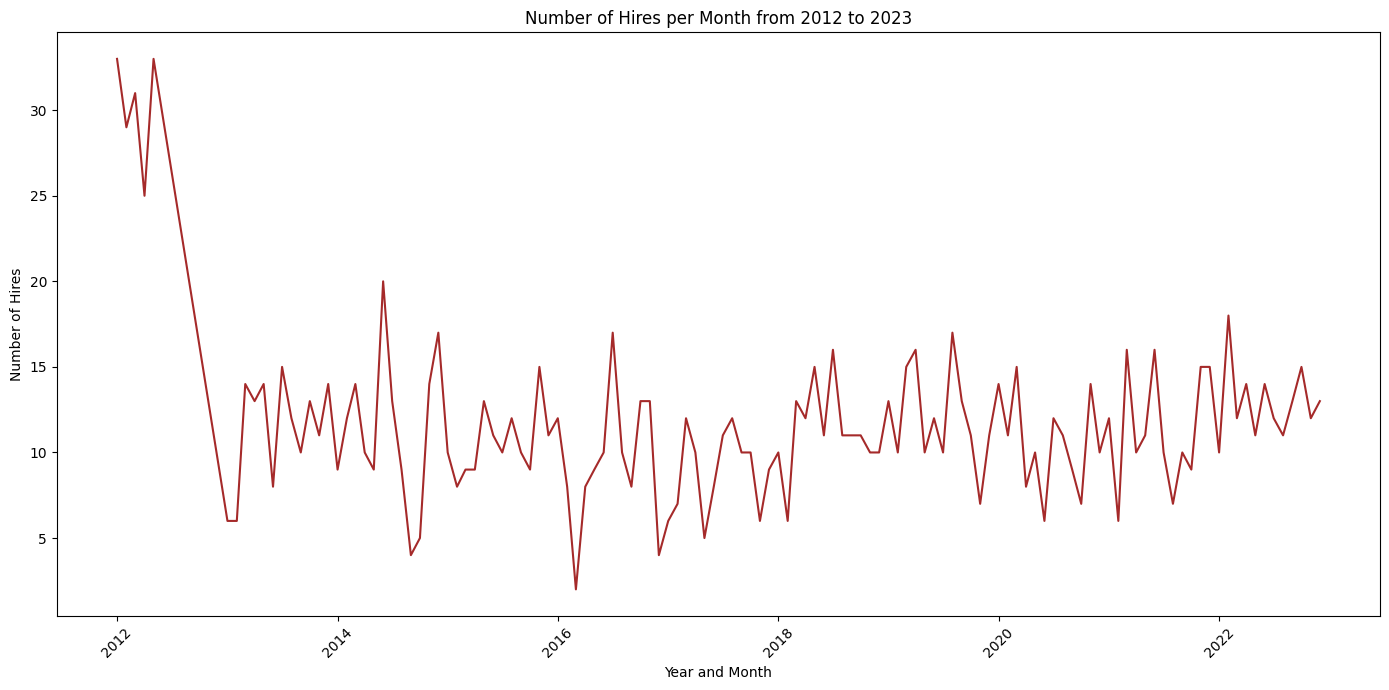

In [936]:
# Color
colors = ['#e3ac6d','#ca7b49','#9f3632','#f1e5d7',]

# Group the data by year and month, then count the number of hires for each group  
em['YearMonth'] = em['HireDate'].dt.to_period('M')  
hire_counts = em.groupby('YearMonth').size().reset_index(name='HireCount')  
  
# Convert 'YearMonth' back to a datetime format for plotting  
hire_counts['YearMonth'] = hire_counts['YearMonth'].dt.to_timestamp()  

# Plotting  
plt.figure(figsize=(14, 7))  
sns.lineplot(data=hire_counts, x='YearMonth', y='HireCount',color='brown')  
plt.title('Number of Hires per Month from 2012 to 2023')  
plt.xlabel('Year and Month')  
plt.ylabel('Number of Hires')  
plt.xticks(rotation=45)  
plt.tight_layout()  
plt.show()  

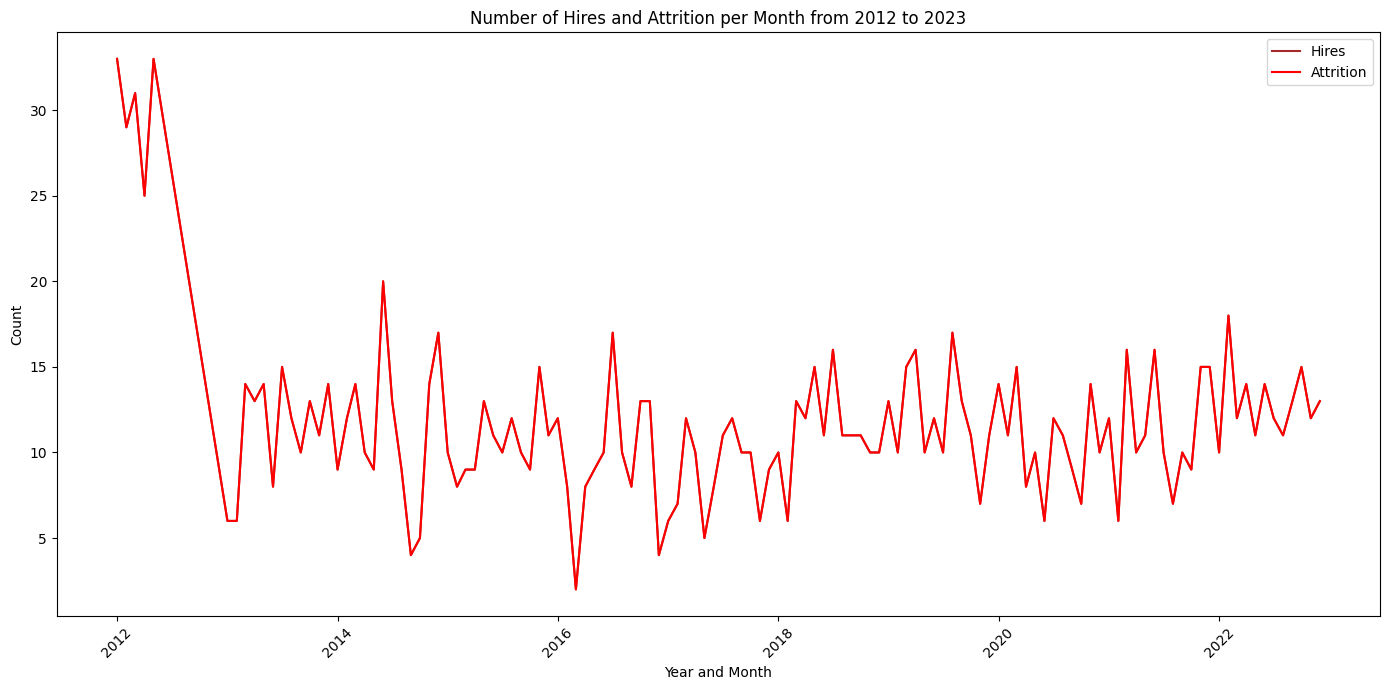

In [943]:
'''
MASIH SALAH NIH KENAPA ATTRITION SAMA HIREDNYA SAMA TOTALNYA
'''

# 1. Group the data by YearMonth and count the number of hires for each group
em['YearMonth'] = em['HireDate'].dt.to_period('M')
hire_counts = em.groupby('YearMonth').size().reset_index(name='HireCount')

# 2. Filter the data for Attrition = 'Yes' and group by YearMonth
# Hanya menghitung 'Yes' dalam kolom Attrition
attrition_counts = em[em['Attrition'] == 'Yes'].groupby('YearMonth').size().reset_index(name='AttritionCount')

# 3. Convert 'YearMonth' back to a datetime format for plotting
hire_counts['YearMonth'] = hire_counts['YearMonth'].dt.to_timestamp()
attrition_counts['YearMonth'] = attrition_counts['YearMonth'].dt.to_timestamp()

# 4. Merge the hire and attrition counts on YearMonth, filling missing values with 0
merged_counts = pd.merge(hire_counts, attrition_counts, on='YearMonth', how='left').fillna({'AttritionCount': 0})

# 5. Plotting
plt.figure(figsize=(14, 7))

# Plot the hires line
sns.lineplot(data=merged_counts, x='YearMonth', y='HireCount', color='brown', label='Hires')

# Plot the attrition line
sns.lineplot(data=merged_counts, x='YearMonth', y='AttritionCount', color='red', label='Attrition')

# Add labels and title
plt.title('Number of Hires and Attrition per Month from 2012 to 2023')  
plt.xlabel('Year and Month')  
plt.ylabel('Count')  
plt.xticks(rotation=45)  
plt.legend()  # Show the legend for the two lines
plt.tight_layout()  
plt.show()


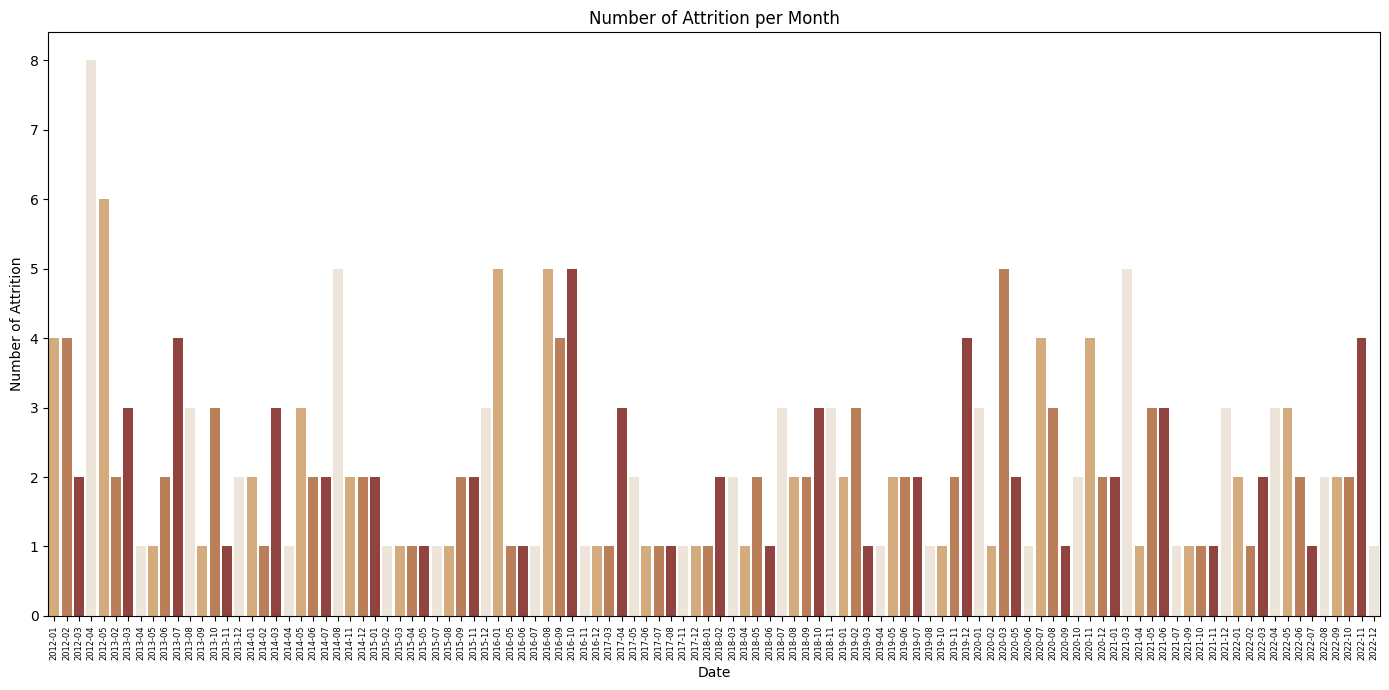

In [932]:
# Group the data by YearMonth and count the number of 'Yes' attrition
em['YearMonth'] = em['HireDate'].dt.to_period('M')

# Color
colors = ['#e3ac6d','#ca7b49','#9f3632','#f1e5d7']

# 'Attrition Yes' by 'YearMonth'
attrition_counts = em[em['Attrition'] == 'Yes'].groupby('YearMonth').size().reset_index(name='AttritionCount')
attrition_counts['YearMonth'] = attrition_counts['YearMonth'].dt.strftime('%Y-%m')

# Plotting bar plot
plt.figure(figsize=(14, 7))
sns.barplot(data=attrition_counts, x='YearMonth', y='AttritionCount', palette=colors)

plt.title('Number of Attrition per Month')
plt.xlabel('Date')
plt.ylabel('Number of Attrition')
plt.xticks(rotation=90, size=6)
plt.tight_layout()
plt.show()

The trend both hiring and attrition rates following a similar pattern over time — highlights an important aspect of employee management: the balance between how many employees leave the company and how many are hired to replace or expand the workforce.

Key Points:
- Peak in 2012: Both hiring and attrition were at their highest in 2012, indicating perhaps a significant change in the company during that time — whether it was due to expansion, restructuring, or external factors influencing employee movement.

- Stabilization Post-2013: After 2012, the trend stabilized, with both hiring and attrition rates becoming more consistent between 2013 and 2023. This could reflect a period of steady growth, retention-focused strategies, and more predictable workforce planning.

- Incresing Seasonal Hiring (2022-2023): The increased hiring trend in 2022-2023 relative to attrition could signal that the company had a higher demand for employees during that period, perhaps due to an expansion, project, or increased business activity. It’s also possible that the company was strategically increasing its workforce to ensure it could meet new challenges or opportunities, such as preparing for a new product launch or scaling operations.

### **Traveling Towards Attrition**

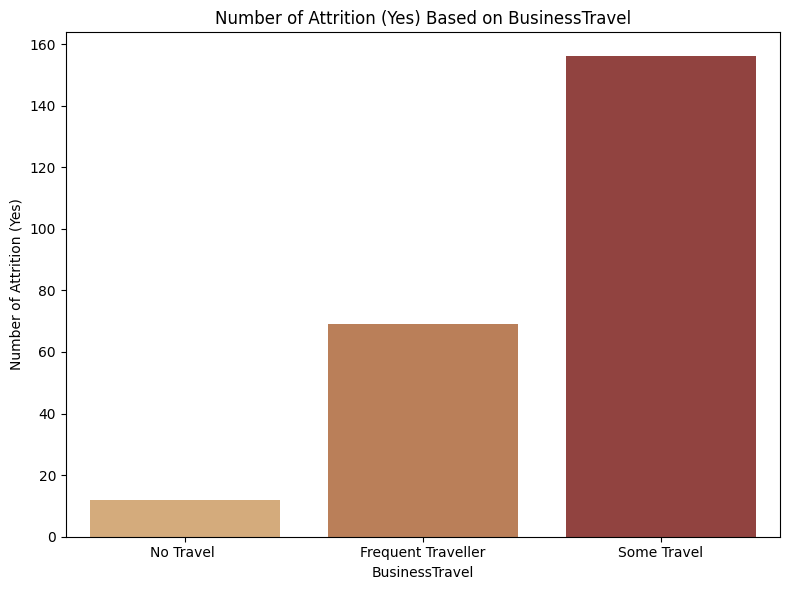

In [923]:
attrition_yes = em[em['Attrition'] == 'Yes']

# Group by 'BusinessTravel' dan hitung jumlah untuk masing-masing
BusinessTravel_counts = attrition_yes.groupby('BusinessTravel').size().reset_index(name='AttritionCount')
BusinessTravel_counts = BusinessTravel_counts.sort_values(by='AttritionCount', ascending=True)

# Plotting bar chart
plt.figure(figsize=(8, 6))
sns.barplot(data=BusinessTravel_counts, x='BusinessTravel', y='AttritionCount', palette=colors)

plt.title('Number of Attrition (Yes) Based on BusinessTravel')
plt.xlabel('BusinessTravel')
plt.ylabel('Number of Attrition (Yes)')
plt.tight_layout()
plt.show()

How travel frequency might correlate with employee attrition, and there are some key patterns that can be helpful for understanding employee behavior. Here's how i break it down and visualize it in Tableau, as well as some considerations for interpreting these results.

Key Insights:
- Employees who never travel are the least likely to leave the company. This could be because they are suited for roles that don't require mobility, which might align with job stability and satisfaction. These employees could be in indoor roles, such as admin, customer support, or roles with fixed responsibilities, which often come with a consistent work-life balance and security.
- Employees who frequently travel (e.g., sales, field engineers, consultants) may be less likely to leave, as they are likely more engaged with their roles. The travel could be part of their job satisfaction and a factor in maintaining job fulfillment, especially if their roles involve interesting challenges, variety, and benefits such as travel allowances, meetings, or networking opportunities.
- Employees who travel occasionally (e.g., hybrid roles) show the highest attrition. These employees might have a more mixed experience of both indoor and outdoor activities, which could create a more complex work-life balance. Hybrid workers need a diverse skill set, and if those needs aren't being met (e.g., inconsistent benefits or unclear expectations), they might be more likely to leave.

Yet, the relationship between business travel frequency and employee attrition is complex, and while the bar chart provides a clear initial view, there are indeed many other factors that could influence this behavior. These factors may not be directly related to travel but could still impact an employee’s decision to stay or leave

### **Demograph**

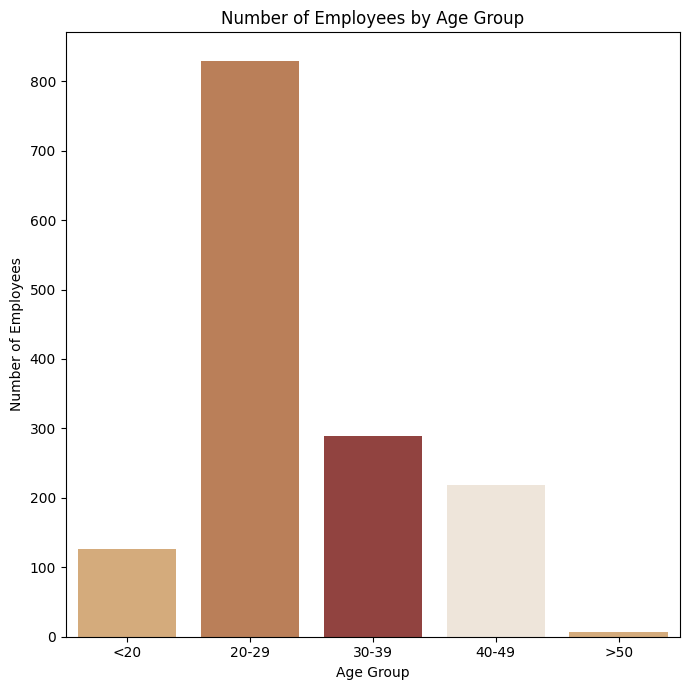

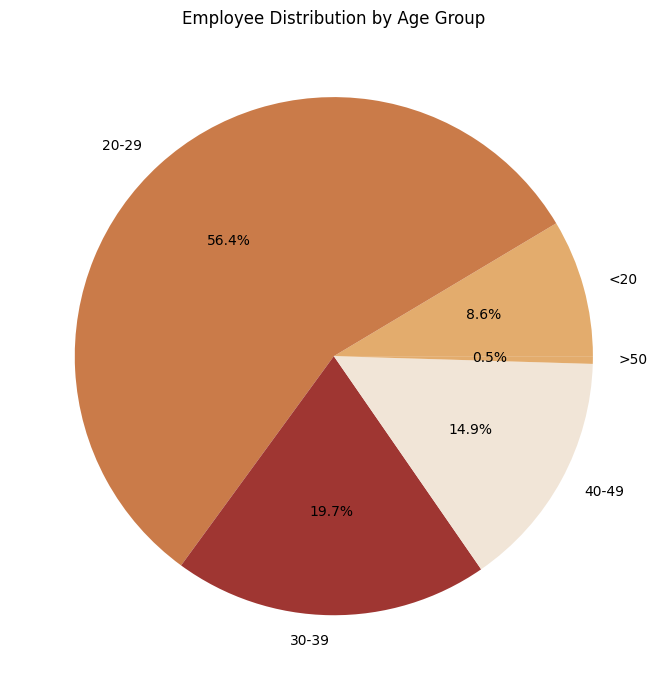

In [929]:
# define bins and labels
bins = [-float('inf'), 20, 29, 39, 49, float('inf')]  # Definisi bin untuk kategori umur
labels = ['<20', '20-29', '30-39', '40-49', '>50']    # Label untuk kategori umur

# age group
em['AgeGroup'] = pd.cut(em['Age'], bins=bins, labels=labels, right=True)

# Emplyee count by Age Group
age_group_counts = em.groupby('AgeGroup').size().reset_index(name='EmployeeCount')

# Plotting bar chart
plt.figure(figsize=(7,7))
sns.barplot(data=age_group_counts, x='AgeGroup', y='EmployeeCount', palette=colors)
plt.title('Number of Employees by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.show()

# Plotting pie chart
plt.figure(figsize=(7, 7))
age_group_counts.set_index('AgeGroup')['EmployeeCount'].plot(kind='pie', autopct='%1.1f%%', colors=colors, legend=False)
plt.title('Employee Distribution by Age Group')
plt.ylabel('')
plt.tight_layout()
plt.show()

**1. Dominance of the 20-29 Age Group:**

The 20-29 age group being the largest is typical in companies in industries like start-ups, technology, F&B, retail, media, and creative agencies. These sectors often hire younger employees due to the dynamic and fast-paced nature of the work.
Actionable Steps: This could suggest that company has a young, dynamic workforce, which may be ideal for innovation-driven industries. However, we should also consider what kind of support and growth opportunities are available to retain these younger employees, especially as they gain experience.

**2. Lower Numbers in the 50+ Age Group:**

The 50+ group being the smallest indicates that the company has fewer employees nearing retirement. This could also reflect challenges or preferences within certain industries that tend to hire younger workers.
Actionable Steps: we might want to explore whether the company has enough retention strategies for older workers (e.g., benefits or flexible working options) to ensure they stay longer or make a smooth transition to retirement.

**3. Under 20 Group:**

The under 20 age group being small might indicate the company generally hires employees who are at least 22 years old, aligning with the typical age at which people graduate from university (around 22 years old with a bachelor’s degree).
Actionable Steps: If the company wants to hire younger employees (perhaps for internships or entry-level roles), consider adding training programs or apprenticeships to target this demographic.

it is a General consensus that employees in the older age groups (30+) are likely to hold more senior or leadership roles due to their accumulated experience and tenure within the organization. As employees grow in experience, they might move into roles that demand more skills, responsibility, and longer-term commitment. This could also explain why the number of employees tends to decrease as the age group gets older, aligns with the concept of a pyramid-shaped workforce. On the other hand, the 20-29 group is more likely to fill entry-level or junior roles, which might explain its large proportion. Actionable Steps: If retention of older employees is a concern, understanding the career development paths available to them could help in creating strategies to encourage them to stay in the company for longer.